In [1]:
import pandas as pd
from pathlib import Path
import pandas_datareader.data as web
import datetime
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
!pip install scikit-learn
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
# ── 1. DICTIONNAIRE DES TICKERS FRED ──
MACRO_TICKERS = {
    "US": "CPIAUCSL",                 # US Consumer Price Index
    "European Union": "CP0000EZ19M086NEST", # Euro Area CPI
    "France": "CP0000FRM086NEST",
    "China": "CHNCPIALLMINMEI",      # China CPI (OCDE)
    "Japan": "CPALCY01JPM661N",
    "India" : "INDCPIALLMINMEI",
    "Africa" : "ZAFCPIALLMINMEI",       # South Africa CPI (Proxy Afrique)
    "Russia" : "RUSCPIALLMINMEI",
    "Middle East": "ISRCPIALLMINMEI", #Isarel CPI (Proxy Moyen-Orient)
    "North America": "CANCPALTT01IXOBSAM",  
    "South America": "BRACPIALLMINMEI", # Brésil CPI (Proxy Amérique du Sud)
    "South East Asia": "IDNCPIALLMINMEI", 
}

In [3]:
# ── 1. Chargement de la base GLOBALE (indicators) ──
dir_global = Path("./indicators")
if dir_global.exists():
    files_global = list(dir_global.glob("*.parquet"))
    df_global = pd.concat([pd.read_parquet(f) for f in files_global], ignore_index=True)
    df_global = df_global.groupby('period').max().reset_index()
    df_global['period'] = pd.to_datetime(df_global['period'])
    df_global = df_global.sort_values('period')
    print(f"✓ Base GLOBALE chargée : {len(df_global)} jours, de {df_global['period'].min().date()} à {df_global['period'].max().date()}")
else:
    df_global = None
    print("⚠ Dossier ./indicators introuvable.")

# ── 2. Chargement de la base RÉGIONALE (indicators_geo) ──
dir_geo = Path("./indicators_geo") # Modifiez si votre dossier s'appelle autrement
if dir_geo.exists():
    files_geo = list(dir_geo.glob("*.parquet"))
    df_geo = pd.concat([pd.read_parquet(f) for f in files_geo], ignore_index=True)
    df_geo = df_geo.groupby(['period', 'region_key']).max().reset_index()
    df_geo['period'] = pd.to_datetime(df_geo['period'])
    df_geo = df_geo.sort_values(['period', 'region_key'])
    print(f"✓ Base RÉGIONALE chargée : {len(df_geo)} lignes, avec les régions {list(df_geo['region_key'].unique())}")
else:
    df_geo = None
    print("⚠ Dossier ./indicators_geo introuvable.")

✓ Base GLOBALE chargée : 4123 jours, de 2015-02-18 à 2026-06-19
✓ Base RÉGIONALE chargée : 53599 lignes, avec les régions ['Africa', 'China', 'European Union', 'France', 'India', 'Japan', 'Lebanon', 'Middle East', 'North America', 'Russia', 'South America', 'South East Asia', 'US']


In [6]:
from pipeline_econometrique_hierarchique import * 

🌍 AUDIT ÉCONOMÉTRIQUE HIÉRARCHIQUE : US | IND. : ATT_WEIGHT

▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
PHASE 1 : COMPÉTITION DES GRANDS THÈMES (MACRO-NARRATIONS)
Objectif : Identifier les secteurs majeurs qui annoncent l'inflation (Lags T+1 à T+6).
Lecture  : Les cases foncées à droite (T > 0) sont vos Indicateurs Avancés robustes.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_finance,0.00,+0.12**,+0.13**,+0.06 (ns),+0.01 (ns),0.00,+0.80***,+0.80***,+0.79***,+0.62***,+0.46***,+0.39***,0.00
att_weight_energy,0.00,0.00,0.00,0.00,+0.02*,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_agriculture,0.00,0.00,0.00,0.00,0.00,0.00,+0.16 (ns),+0.08 (ns),+0.04 (ns),0.00,0.00,0.00,0.00
att_weight_tech,0.00,0.00,0.00,0.00,0.00,0.00,+0.42***,+0.30***,+0.24**,+0.05*,0.00,+0.01**,0.00
att_weight_industry,0.00,-0.08***,-0.04***,0.00,0.00,0.00,0.00,0.00,+0.08 (ns),+0.05 (ns),+0.06*,+0.15**,0.00
att_weight_commodities,0.00,+0.04 (ns),+0.06 (ns),+0.08**,+0.06*,0.00,+0.04 (ns),0.00,0.00,0.00,0.00,0.00,0.00
att_weight_real_estate,+0.32***,+0.32***,+0.23***,+0.13**,+0.11**,+0.05***,+0.33*,+0.28 (ns),+0.22 (ns),+0.16 (ns),+0.06 (ns),+0.07 (ns),0.00
att_weight_transport,0.00,0.00,0.00,0.00,+0.01 (ns),0.00,+0.32**,+0.24**,+0.19 (ns),+0.04 (ns),0.00,0.00,0.00
_INERTIE_MACRO_,+1.06***,+1.28***,+1.41***,+1.57***,+1.77***,+1.92***,N/A,N/A,N/A,N/A,N/A,N/A,N/A




▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
PHASE 2 : DEEP DIVE SUR LES THÈMES GAGNANTS (4 trouvés)
Objectif : Pour chaque thème vainqueur, isoler la SOUS-CATÉGORIE exacte qui porte le signal.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

FORAGE DANS LE SECTEUR : ATT_WEIGHT_FINANCE


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_finance_banks,0.00,0.00,0.00,0.00,0.00,0.00,+0.34*,+0.38*,+0.37*,+0.34 (ns),+0.08 (ns),+0.11 (ns),+0.00 (ns)
att_weight_finance_central_banks,+0.06*,+0.09*,+0.07 (ns),+0.01 (ns),+0.02 (ns),+0.00 (ns),+0.07 (ns),0.00,0.00,0.00,+0.17 (ns),0.00,0.00
att_weight_finance_credit,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.33**,0.00,0.00
att_weight_finance_financial_markets,0.00,0.00,0.00,0.00,0.00,0.00,0.00,+0.01 (ns),+0.10 (ns),+0.15 (ns),+0.25 (ns),+0.28**,+0.31***
att_weight_finance_international_orgs,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_private_debt,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,+0.10 (ns),+0.25*,+0.54**,+0.29***,+0.18**
att_weight_finance_regulation,0.00,+0.02**,+0.07***,+0.04**,0.00,0.00,+0.17 (ns),+0.17 (ns),+0.12 (ns),+0.08 (ns),+0.35*,0.00,0.00
att_weight_finance_sovereign_debt,+0.12*,+0.13**,+0.14**,+0.13**,+0.07*,0.00,+0.67***,+0.60***,+0.42**,+0.22 (ns),+0.07 (ns),0.00,0.00
att_weight_finance_systemic_risk,0.00,0.00,0.00,0.00,0.00,0.00,0.00,+0.01 (ns),+0.02 (ns),+0.03 (ns),+0.36**,+0.13*,+0.20**
_INERTIE_MACRO_,+1.12***,+1.25***,+1.40***,+1.58***,+1.75***,+1.93***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  Meilleure Narration détectée : ATT_WEIGHT_FINANCE_SOVEREIGN_DEBT (Impact: 0.14)

FORAGE DANS LE SECTEUR : ATT_WEIGHT_INDUSTRY


...

  ⚠ Aucune sous-catégorie n'a survécu à l'isolation.

FORAGE DANS LE SECTEUR : ATT_WEIGHT_COMMODITIES


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_commodities_extraction,0.00,0.00,+0.02*,+0.07**,+0.05*,+0.01 (ns),+1.42***,+1.48***,0.00,0.00,0.00,0.00,0.00
att_weight_commodities_market_prices,+0.04**,+0.09***,+0.18***,+0.21***,+0.18***,+0.11***,+0.55***,+0.40**,0.00,0.00,0.00,0.00,0.00
att_weight_commodities_materials,0.00,0.00,0.00,0.00,0.00,0.00,-1.13***,-1.20***,0.00,0.00,0.00,0.00,0.00
att_weight_commodities_regulation,0.00,0.00,0.00,0.00,0.00,+0.01 (ns),+0.50***,+0.49***,0.00,0.00,0.00,0.00,0.00
att_weight_commodities_risks,0.00,0.00,0.00,0.00,0.00,0.00,+0.09 (ns),+0.04 (ns),0.00,0.00,0.00,0.00,0.00
_INERTIE_MACRO_,+1.16***,+1.28***,+1.46***,+1.62***,+1.78***,+1.94***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  Meilleure Narration détectée : ATT_WEIGHT_COMMODITIES_MARKET_PRICES (Impact: 0.21)

FORAGE DANS LE SECTEUR : ATT_WEIGHT_REAL_ESTATE


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_real_estate_construction,0.00,0.00,0.00,0.00,0.00,0.00,+0.22 (ns),+0.15 (ns),+0.12 (ns),+0.08 (ns),+0.10 (ns),+0.08 (ns),+0.08 (ns)
att_weight_real_estate_financing,0.00,0.00,+0.02 (ns),0.00,0.00,0.00,+0.61***,+0.65***,+0.64***,+0.58***,+0.48***,+0.34**,+0.29**
att_weight_real_estate_market,+0.12***,+0.12***,+0.13**,+0.06**,+0.06**,+0.03**,+0.00 (ns),0.00,0.00,0.00,0.00,0.00,0.00
att_weight_real_estate_regulation,+0.13***,+0.13***,+0.10**,+0.10***,+0.07**,+0.03**,+0.07 (ns),+0.01 (ns),0.00,0.00,0.00,0.00,0.00
att_weight_real_estate_urbanism,0.00,0.00,0.00,0.00,0.00,0.00,+0.60***,+0.57***,+0.53***,+0.48***,+0.46**,+0.45**,+0.47***
_INERTIE_MACRO_,+1.14***,+1.31***,+1.48***,+1.63***,+1.78***,+1.93***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  Meilleure Narration détectée : ATT_WEIGHT_REAL_ESTATE_REGULATION (Impact: 0.13)


▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
PHASE 3 : SIMULATION DE CRISE (FONCTIONS DE RÉPONSE IMPULSIONNELLE)
Objectif : Visualiser l'impact économique sur 12 mois d'un choc sur les meilleurs narratifs.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_COMMODITIES_MARKET_PRICES


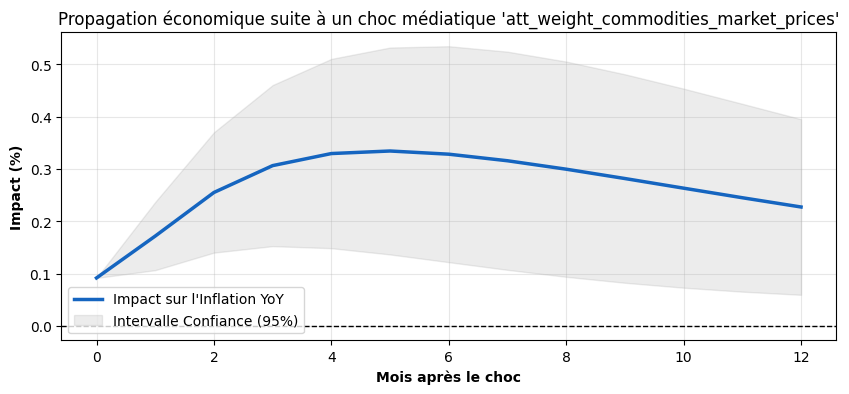


Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_FINANCE_SOVEREIGN_DEBT


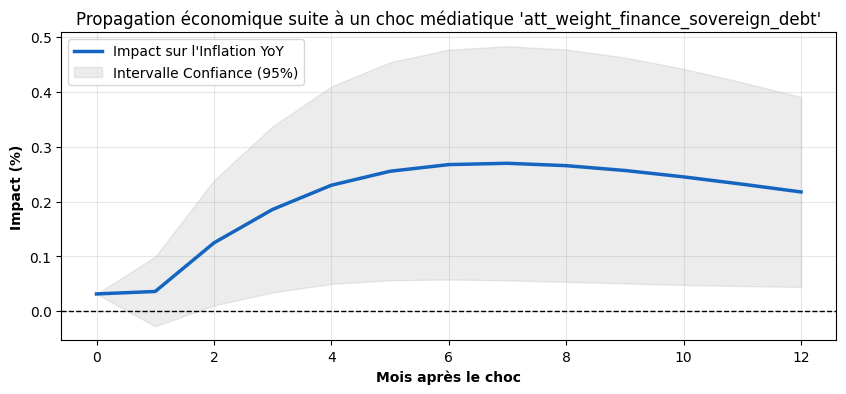


Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_REAL_ESTATE_REGULATION


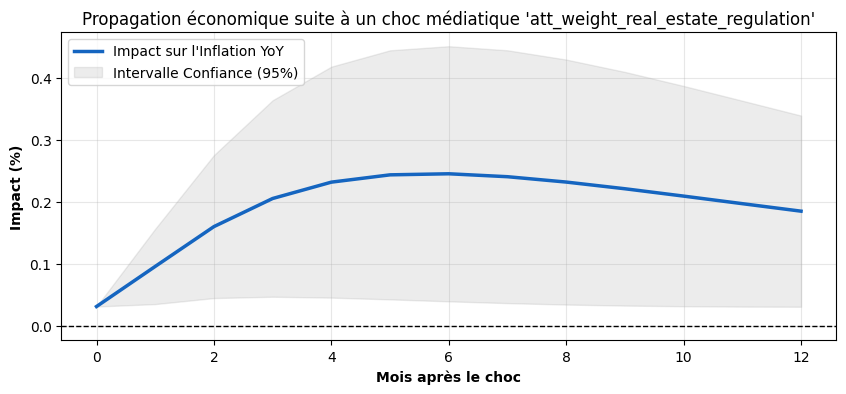


✅ FIN DE L'AUDIT POUR US



In [7]:
# On définit tous les grands thèmes que l'on veut jeter dans l'arène de la Phase 1
mes_grands_secteurs = [
    "finance", "energy", "agriculture", "tech", 
    "industry", "commodities", "real_estate", "transport"
]

# On lance l'usine (Exemple pour les États-Unis)
run_hierarchical_pipeline(
    df_geo = df_geo, 
    region = "US", 
    type_gdelt = "att_weight", 
    parent_sectors = mes_grands_secteurs,
    macro_tickers_dict = MACRO_TICKERS
)

🌍 AUDIT ÉCONOMÉTRIQUE HIÉRARCHIQUE : FRANCE | IND. : ATT_WEIGHT

▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
PHASE 1 : COMPÉTITION DES GRANDS THÈMES (MACRO-NARRATIONS)
Objectif : Identifier les secteurs majeurs qui annoncent l'inflation (Lags T+1 à T+6).
Lecture  : Les cases foncées à droite (T > 0) sont vos Indicateurs Avancés robustes.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_finance,+0.41***,+0.32***,+0.24***,+0.20***,+0.11**,+0.07**,+0.41***,+0.32***,0.00,0.00,0.00,0.00,0.00
att_weight_energy,+0.15 (ns),+0.14*,+0.09 (ns),+0.06 (ns),+0.08 (ns),+0.00 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_agriculture,+0.46***,+0.44***,+0.36***,+0.25***,+0.13**,+0.05*,+0.00 (ns),0.00,0.00,0.00,0.00,0.00,0.00
att_weight_tech,+0.29***,+0.29***,+0.35***,+0.33***,+0.23***,+0.08***,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry,-0.24**,-0.21**,-0.16**,-0.04 (ns),-0.02 (ns),-0.02 (ns),+0.08 (ns),+0.02 (ns),0.00,0.00,0.00,0.00,0.00
att_weight_commodities,-0.01 (ns),-0.04 (ns),-0.11 (ns),-0.10 (ns),-0.05 (ns),0.00,+0.09 (ns),+0.07 (ns),0.00,0.00,0.00,0.00,0.00
att_weight_real_estate,-0.07 (ns),-0.07 (ns),-0.14 (ns),-0.13*,-0.09*,0.00,+0.31**,+0.30**,0.00,0.00,0.00,+0.04***,+0.04***
att_weight_transport,+0.15 (ns),+0.13*,+0.14*,+0.15**,+0.09*,+0.07**,+0.00 (ns),0.00,0.00,0.00,0.00,0.00,0.00
_INERTIE_MACRO_,+1.36***,+1.49***,+1.64***,+1.72***,+1.82***,+1.88***,N/A,N/A,N/A,N/A,N/A,N/A,N/A




▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
PHASE 2 : DEEP DIVE SUR LES THÈMES GAGNANTS (5 trouvés)
Objectif : Pour chaque thème vainqueur, isoler la SOUS-CATÉGORIE exacte qui porte le signal.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

FORAGE DANS LE SECTEUR : ATT_WEIGHT_FINANCE


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_finance_banks,0.00,+0.07 (ns),+0.15*,+0.11 (ns),+0.08 (ns),+0.02 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_central_banks,+0.23*,+0.14 (ns),0.00,0.00,0.00,+0.07 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_credit,+0.13 (ns),+0.18**,+0.19***,+0.11*,+0.09*,+0.01 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_financial_markets,-0.09 (ns),-0.07 (ns),-0.10 (ns),-0.09 (ns),-0.04 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_international_orgs,+0.01 (ns),+0.04 (ns),+0.03 (ns),0.00,-0.01 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_private_debt,-0.55***,-0.52***,-0.48***,-0.35***,-0.23***,-0.02 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_regulation,+0.16*,+0.12 (ns),+0.11 (ns),+0.05 (ns),+0.04 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_sovereign_debt,+0.61***,+0.51***,+0.47***,+0.38***,+0.21***,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_systemic_risk,+0.02 (ns),+0.02 (ns),-0.03 (ns),-0.01 (ns),-0.02 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
_INERTIE_MACRO_,+1.49***,+1.59***,+1.69***,+1.77***,+1.85***,+1.89***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  Meilleure Narration détectée : ATT_WEIGHT_FINANCE_SOVEREIGN_DEBT (Impact: 0.61)

FORAGE DANS LE SECTEUR : ATT_WEIGHT_AGRICULTURE


...

  Meilleure Narration détectée : ATT_WEIGHT_TECH_INFRASTRUCTURE (Impact: 0.29)

FORAGE DANS LE SECTEUR : ATT_WEIGHT_INDUSTRY


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_industry_factories,-0.04 (ns),-0.01 (ns),-0.01 (ns),+0.00 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry_logistics,+0.00 (ns),0.00,-0.03 (ns),-0.04 (ns),-0.02 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry_productivity,+0.08 (ns),+0.04 (ns),+0.02 (ns),+0.01 (ns),0.00,+0.02 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry_regulation,-0.20**,-0.19**,-0.21**,-0.09*,-0.05**,0.00,0.00,0.00,0.00,0.00,0.00,+0.04*,0.00
att_weight_industry_risks,+0.08 (ns),+0.09 (ns),+0.10 (ns),+0.05 (ns),+0.04 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry_supply_chains,+0.16*,+0.16*,+0.08 (ns),+0.10 (ns),+0.06 (ns),0.00,+0.04***,+0.03***,0.00,0.00,0.00,+0.05*,0.00
_INERTIE_MACRO_,+1.53***,+1.61***,+1.75***,+1.77***,+1.83***,+1.89***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  Meilleure Narration détectée : ATT_WEIGHT_INDUSTRY_REGULATION (Impact: 0.21)

FORAGE DANS LE SECTEUR : ATT_WEIGHT_TRANSPORT


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_transport_costs,+0.18*,+0.16*,+0.13 (ns),+0.01 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_transport_infrastructure,0.00,0.00,-0.08 (ns),-0.02 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_transport_international_trade,+0.03 (ns),+0.05 (ns),+0.08 (ns),+0.02 (ns),+0.01 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_transport_logistics,+0.39***,+0.36***,+0.32***,+0.31***,+0.18***,+0.09***,0.00,0.00,0.00,0.00,0.00,0.00,-0.04***
att_weight_transport_modes,-0.06 (ns),-0.06 (ns),0.00,0.00,0.00,+0.01 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_transport_regulation,-0.19*,-0.11 (ns),-0.06 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_transport_risks,+0.06 (ns),+0.01 (ns),+0.00 (ns),0.00,-0.01 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
_INERTIE_MACRO_,+1.53***,+1.63***,+1.71***,+1.77***,+1.83***,+1.90***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  Meilleure Narration détectée : ATT_WEIGHT_TRANSPORT_LOGISTICS (Impact: 0.39)


▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
PHASE 3 : SIMULATION DE CRISE (FONCTIONS DE RÉPONSE IMPULSIONNELLE)
Objectif : Visualiser l'impact économique sur 12 mois d'un choc sur les meilleurs narratifs.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_FINANCE_SOVEREIGN_DEBT


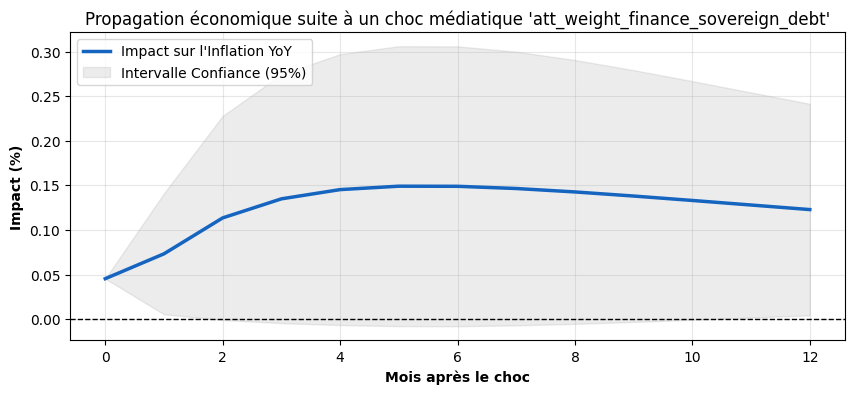


Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_AGRICULTURE_INFRASTRUCTURE_TECH


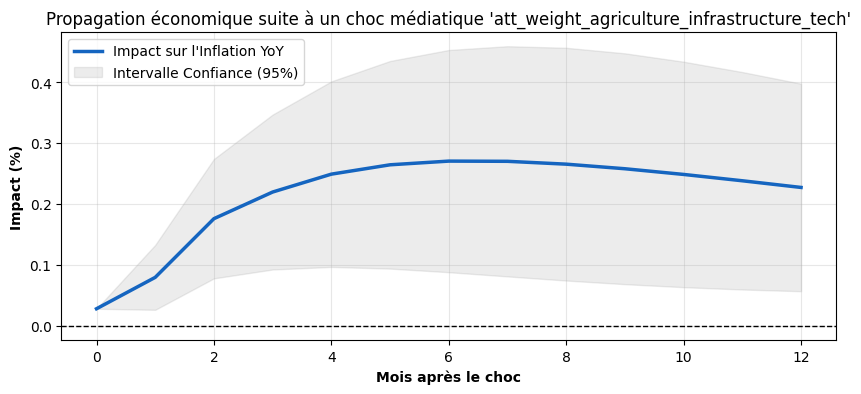


Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_TRANSPORT_LOGISTICS


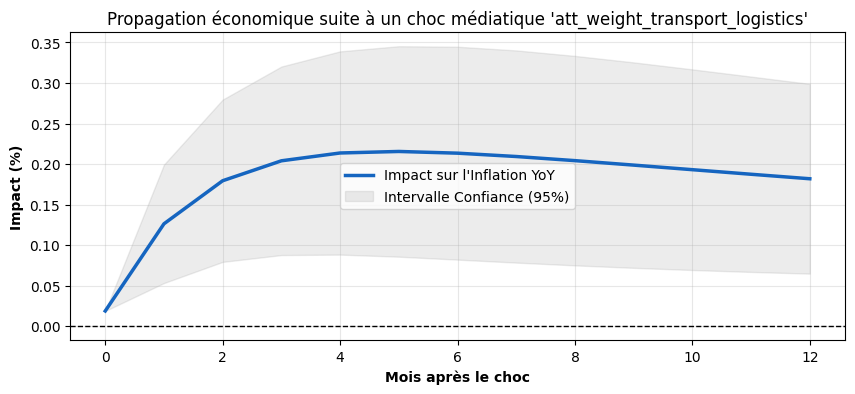


Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_TECH_INFRASTRUCTURE


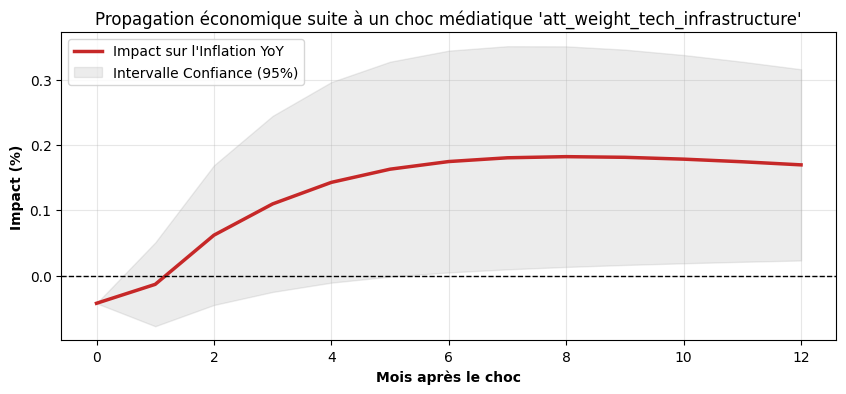


Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_INDUSTRY_REGULATION


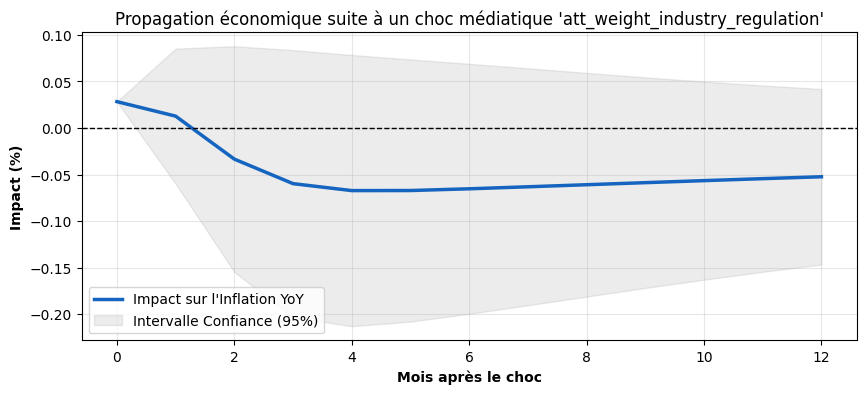


✅ FIN DE L'AUDIT POUR FRANCE



In [ ]:
# On définit tous les grands thèmes que l'on veut jeter dans l'arène de la Phase 1
mes_grands_secteurs = [
    "finance", "energy", "agriculture", "tech", 
    "industry", "commodities", "real_estate", "transport"
]

# On lance l'usine (Exemple pour les États-Unis)
run_hierarchical_pipeline(
    df_geo = df_geo, 
    region = "France", 
    type_gdelt = "att_weight", 
    parent_sectors = mes_grands_secteurs,
    macro_tickers_dict = MACRO_TICKERS
)

🌍 AUDIT ÉCONOMÉTRIQUE HIÉRARCHIQUE : CHINA | IND. : ATT_WEIGHT

▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 PHASE 1 : COMPÉTITION DES GRANDS THÈMES (MACRO-NARRATIONS)
Objectif : Identifier les secteurs majeurs qui annoncent l'inflation (Lags T+1 à T+6).
Lecture  : Les cases foncées à droite (T > 0) sont vos Indicateurs Avancés robustes.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_finance,+0.03 (ns),+0.11*,+0.14***,+0.18***,+0.16*,+0.12***,+0.11 (ns),0.00,0.00,0.00,0.00,0.00,0.00
att_weight_energy,0.00,0.00,0.00,0.00,+0.09 (ns),0.00,-0.04 (ns),0.00,0.00,-0.04 (ns),-0.00 (ns),0.00,0.00
att_weight_agriculture,0.00,0.00,0.00,0.00,+0.15 (ns),0.00,0.00,0.00,0.00,-0.02 (ns),0.00,0.00,0.00
att_weight_tech,-0.17*,-0.08 (ns),-0.08 (ns),-0.06 (ns),-0.09 (ns),0.00,-0.34***,0.00,0.00,-0.21**,-0.10 (ns),-0.01 (ns),0.00
att_weight_industry,-0.14**,-0.12*,-0.04 (ns),0.00,-0.12 (ns),-0.01 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_commodities,0.00,+0.07 (ns),+0.05*,+0.05*,+0.07 (ns),0.00,-0.33***,0.00,0.00,-0.29***,-0.34***,-0.38***,-0.37***
att_weight_real_estate,+0.22***,+0.06 (ns),0.00,0.00,-0.05 (ns),0.00,+0.04 (ns),0.00,0.00,0.00,0.00,0.00,+0.01 (ns)
att_weight_transport,0.00,0.00,0.00,-0.00 (ns),-0.07 (ns),-0.03 (ns),-0.21**,0.00,0.00,-0.22**,-0.21**,-0.20**,-0.20***
_INERTIE_MACRO_,+0.47***,+0.58***,+0.67***,+0.79***,+0.98***,+1.04***,N/A,N/A,N/A,N/A,N/A,N/A,N/A




▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 PHASE 2 : DEEP DIVE SUR LES THÈMES GAGNANTS (3 trouvés)
Objectif : Pour chaque thème vainqueur, isoler la SOUS-CATÉGORIE exacte qui porte le signal.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

🔍 FORAGE DANS LE SECTEUR : ATT_WEIGHT_FINANCE


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_finance_banks,0.00,0.00,0.00,+0.12 (ns),+0.09 (ns),+0.07*,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_central_banks,0.00,+0.15***,+0.14***,+0.04 (ns),+0.03 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_credit,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_financial_markets,0.00,0.00,0.00,+0.03 (ns),+0.05 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_international_orgs,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_private_debt,0.00,0.00,0.00,0.00,0.00,+0.01 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_regulation,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_sovereign_debt,0.00,0.00,0.00,0.00,0.00,+0.03 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_systemic_risk,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
_INERTIE_MACRO_,+0.24***,+0.53***,+0.63***,+0.76***,+0.93***,+1.05***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  🏆 Meilleure Narration détectée : ATT_WEIGHT_FINANCE_CENTRAL_BANKS (Impact: 0.15)

🔍 FORAGE DANS LE SECTEUR : ATT_WEIGHT_INDUSTRY


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_industry_factories,+0.12 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry_logistics,-0.08 (ns),-0.03 (ns),0.00,-0.01 (ns),-0.01 (ns),-0.04 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry_productivity,+0.15 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry_regulation,-0.31**,-0.16*,-0.09*,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry_risks,-0.07 (ns),0.00,0.00,0.00,0.00,+0.00 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry_supply_chains,-0.11 (ns),-0.03 (ns),0.00,0.00,0.00,0.00,0.00,-0.02***,0.00,0.00,0.00,0.00,0.00
_INERTIE_MACRO_,+0.59***,+0.63***,+0.72***,+0.81***,+0.94***,+1.07***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  🏆 Meilleure Narration détectée : ATT_WEIGHT_INDUSTRY_REGULATION (Impact: 0.31)

🔍 FORAGE DANS LE SECTEUR : ATT_WEIGHT_REAL_ESTATE


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_real_estate_construction,0.00,-0.06 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,+0.13**,0.00,+0.34***
att_weight_real_estate_financing,0.00,+0.11*,+0.11**,+0.09*,+0.07 (ns),+0.07 (ns),0.00,0.00,0.00,-0.19***,-0.20***,0.00,-0.22**
att_weight_real_estate_market,0.00,+0.15**,+0.02 (ns),+0.06 (ns),+0.02 (ns),+0.04 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_real_estate_regulation,0.00,+0.05*,0.00,0.00,0.00,-0.01 (ns),-0.03***,0.00,0.00,-0.32***,-0.41***,0.00,-0.42***
att_weight_real_estate_urbanism,0.00,-0.09*,0.00,0.00,-0.00 (ns),-0.03 (ns),0.00,0.00,0.00,-0.03 (ns),0.00,0.00,+0.00 (ns)
_INERTIE_MACRO_,+0.24***,+0.68***,+0.77***,+0.87***,+0.99***,+1.11***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  🏆 Meilleure Narration détectée : ATT_WEIGHT_REAL_ESTATE_MARKET (Impact: 0.15)


▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 PHASE 3 : SIMULATION DE CRISE (FONCTIONS DE RÉPONSE IMPULSIONNELLE)
Objectif : Visualiser l'impact économique sur 12 mois d'un choc sur les meilleurs narratifs.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

💥 Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_INDUSTRY_REGULATION


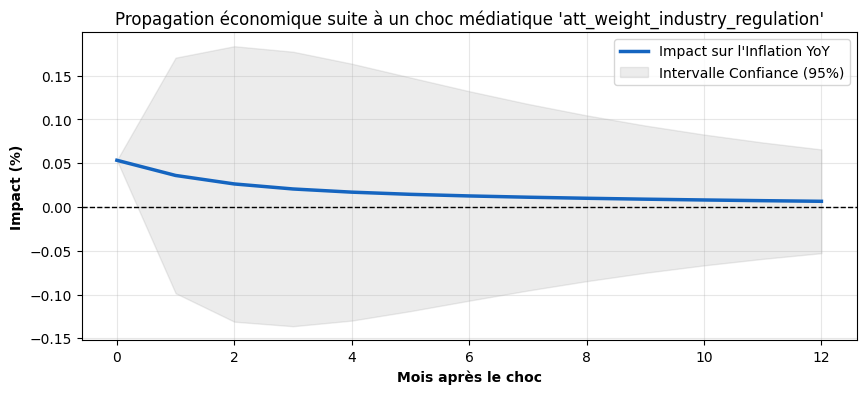


💥 Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_FINANCE_CENTRAL_BANKS


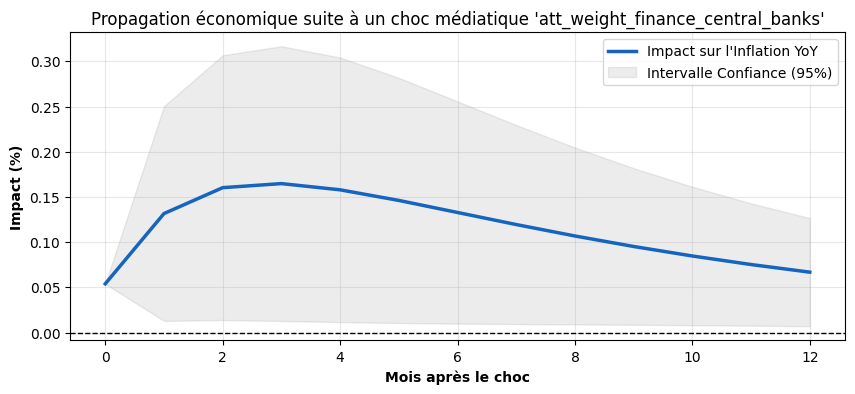


💥 Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_REAL_ESTATE_MARKET


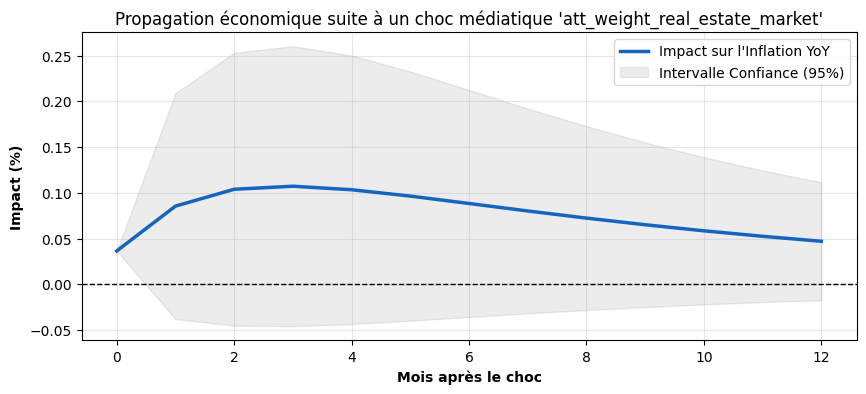


✅ FIN DE L'AUDIT POUR CHINA



In [7]:
# On définit tous les grands thèmes que l'on veut jeter dans l'arène de la Phase 1
mes_grands_secteurs = [
    "finance", "energy", "agriculture", "tech", 
    "industry", "commodities", "real_estate", "transport"
]

# On lance l'usine (Exemple pour les États-Unis)
run_hierarchical_pipeline(
    df_geo = df_geo, 
    region = "China", 
    type_gdelt = "att_weight", 
    parent_sectors = mes_grands_secteurs,
    macro_tickers_dict = MACRO_TICKERS
)

🌍 AUDIT ÉCONOMÉTRIQUE HIÉRARCHIQUE : MIDDLE EAST | IND. : ATT_WEIGHT

▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 PHASE 1 : COMPÉTITION DES GRANDS THÈMES (MACRO-NARRATIONS)
Objectif : Identifier les secteurs majeurs qui annoncent l'inflation (Lags T+1 à T+6).
Lecture  : Les cases foncées à droite (T > 0) sont vos Indicateurs Avancés robustes.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_finance,+0.04 (ns),+0.09 (ns),+0.06 (ns),+0.11 (ns),+0.01 (ns),+0.01 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_energy,+0.16 (ns),+0.21**,+0.22***,+0.20***,+0.08**,+0.05*,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_agriculture,+0.27**,+0.20*,+0.19*,+0.14 (ns),+0.01 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_tech,-0.08 (ns),-0.04 (ns),-0.03 (ns),+0.02 (ns),0.00,-0.00 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry,-0.34***,-0.24**,-0.17*,-0.12 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_commodities,+0.07 (ns),+0.04 (ns),-0.01 (ns),-0.06 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_real_estate,+0.22**,+0.11 (ns),+0.09 (ns),+0.10 (ns),+0.10**,+0.08**,+0.17***,+0.12***,+0.03**,+0.09***,+0.09**,+0.05**,0.00
att_weight_transport,-0.08 (ns),-0.09 (ns),-0.07 (ns),-0.05 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
_INERTIE_MACRO_,+1.51***,+1.60***,+1.67***,+1.72***,+1.76***,+1.82***,N/A,N/A,N/A,N/A,N/A,N/A,N/A




▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 PHASE 2 : DEEP DIVE SUR LES THÈMES GAGNANTS (4 trouvés)
Objectif : Pour chaque thème vainqueur, isoler la SOUS-CATÉGORIE exacte qui porte le signal.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

🔍 FORAGE DANS LE SECTEUR : ATT_WEIGHT_ENERGY


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_energy_fossil,+0.04 (ns),+0.04 (ns),+0.00 (ns),0.00,-0.02 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_energy_infrastructures,+0.15 (ns),+0.04 (ns),0.00,+0.10 (ns),+0.11**,+0.06**,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_energy_nuclear,+0.04 (ns),+0.13 (ns),+0.16**,+0.04 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_energy_regulation,0.00,0.00,-0.00 (ns),0.00,+0.03 (ns),+0.02 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_energy_renewables,+0.06 (ns),+0.11 (ns),+0.12*,+0.11**,+0.05 (ns),+0.02 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_energy_risks,-0.00 (ns),0.00,0.00,0.00,+0.05 (ns),+0.02 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
_INERTIE_MACRO_,+1.55***,+1.64***,+1.69***,+1.75***,+1.81***,+1.85***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  🏆 Meilleure Narration détectée : ATT_WEIGHT_ENERGY_NUCLEAR (Impact: 0.16)

🔍 FORAGE DANS LE SECTEUR : ATT_WEIGHT_AGRICULTURE


...

  🏆 Meilleure Narration détectée : ATT_WEIGHT_AGRICULTURE_INFRASTRUCTURE_TECH (Impact: 0.20)

🔍 FORAGE DANS LE SECTEUR : ATT_WEIGHT_INDUSTRY


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_industry_factories,+0.12 (ns),+0.09 (ns),+0.10 (ns),+0.12 (ns),0.00,0.00,0.00,0.00,-0.21 (ns),-0.16*,0.00,0.00,-0.29*
att_weight_industry_logistics,+0.04 (ns),+0.01 (ns),+0.01 (ns),-0.03 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.08 (ns)
att_weight_industry_productivity,-0.12 (ns),-0.08 (ns),-0.10 (ns),-0.06 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry_regulation,-0.33***,-0.25***,-0.20**,-0.16**,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry_risks,+0.11 (ns),+0.05 (ns),+0.04 (ns),+0.03 (ns),0.00,0.00,0.00,0.00,-0.17 (ns),-0.09 (ns),0.00,0.00,-0.14 (ns)
att_weight_industry_supply_chains,+0.20**,+0.20**,+0.18**,+0.15**,+0.03**,0.00,0.00,0.00,-0.01 (ns),0.00,0.00,0.00,-0.00 (ns)
_INERTIE_MACRO_,+1.62***,+1.66***,+1.72***,+1.79***,+1.76***,+1.82***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  🏆 Meilleure Narration détectée : ATT_WEIGHT_INDUSTRY_REGULATION (Impact: 0.33)

🔍 FORAGE DANS LE SECTEUR : ATT_WEIGHT_REAL_ESTATE


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_real_estate_construction,0.00,0.00,0.00,+0.01 (ns),+0.03 (ns),+0.02 (ns),+0.50***,+0.44***,+0.47***,+0.61***,+0.56***,+0.55***,+0.67***
att_weight_real_estate_financing,0.00,0.00,0.00,0.00,0.00,+0.01 (ns),0.00,0.00,0.00,-0.03 (ns),-0.07 (ns),-0.12 (ns),-0.15 (ns)
att_weight_real_estate_market,+0.44***,+0.36***,+0.29***,+0.27***,+0.19***,+0.09**,0.00,0.00,0.00,0.00,0.00,-0.02 (ns),-0.27**
att_weight_real_estate_regulation,0.00,0.00,+0.01 (ns),+0.05 (ns),+0.07 (ns),+0.05 (ns),0.00,0.00,0.00,+0.02 (ns),+0.10 (ns),+0.15**,+0.33**
att_weight_real_estate_urbanism,-0.12*,-0.11**,-0.08**,-0.09*,-0.03 (ns),+0.01 (ns),+0.05 (ns),0.00,0.00,0.00,0.00,0.00,+0.00 (ns)
_INERTIE_MACRO_,+1.54***,+1.60***,+1.65***,+1.73***,+1.78***,+1.84***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  🏆 Meilleure Narration détectée : ATT_WEIGHT_REAL_ESTATE_MARKET (Impact: 0.44)


▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 PHASE 3 : SIMULATION DE CRISE (FONCTIONS DE RÉPONSE IMPULSIONNELLE)
Objectif : Visualiser l'impact économique sur 12 mois d'un choc sur les meilleurs narratifs.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

💥 Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_REAL_ESTATE_MARKET


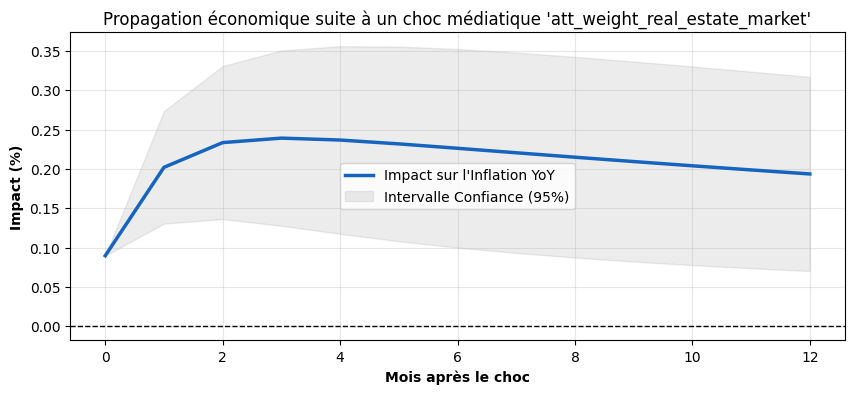


💥 Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_INDUSTRY_REGULATION


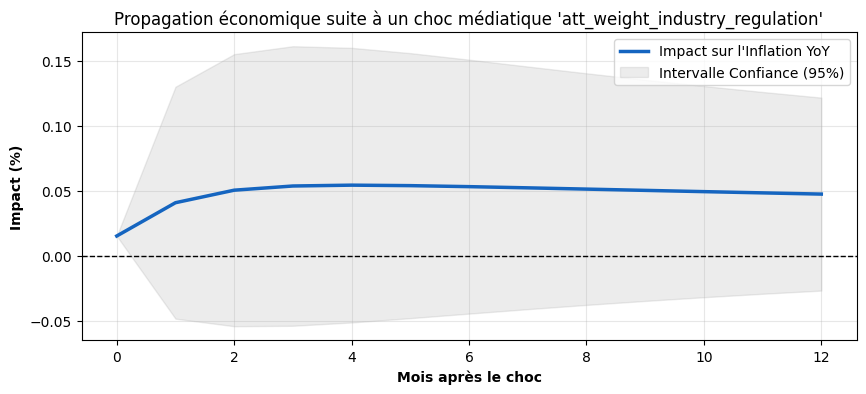


💥 Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_AGRICULTURE_INFRASTRUCTURE_TECH


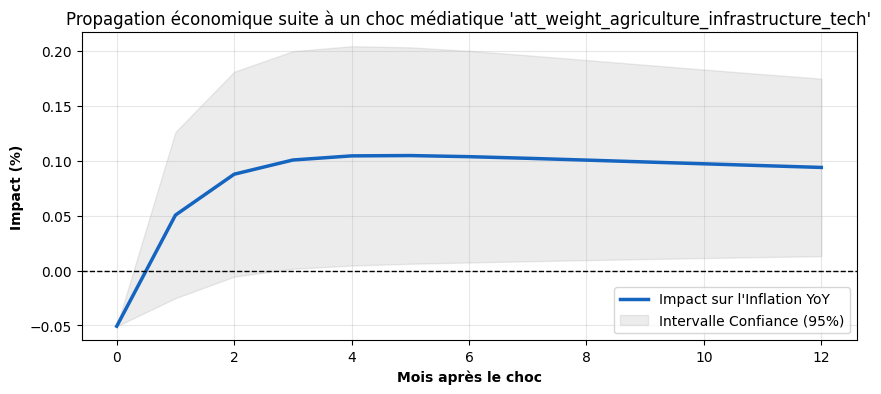


💥 Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_ENERGY_NUCLEAR


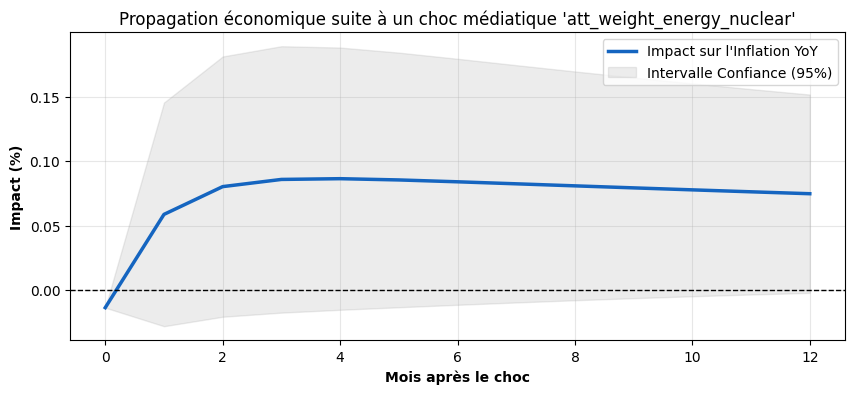


✅ FIN DE L'AUDIT POUR MIDDLE EAST



In [8]:
# On définit tous les grands thèmes que l'on veut jeter dans l'arène de la Phase 1
mes_grands_secteurs = [
    "finance", "energy", "agriculture", "tech", 
    "industry", "commodities", "real_estate", "transport"
]

# On lance l'usine (Exemple pour les États-Unis)
run_hierarchical_pipeline(
    df_geo = df_geo, 
    region = "Middle East", 
    type_gdelt = "att_weight", 
    parent_sectors = mes_grands_secteurs,
    macro_tickers_dict = MACRO_TICKERS
)

🌍 AUDIT ÉCONOMÉTRIQUE HIÉRARCHIQUE : SOUTH AMERICA | IND. : ATT_WEIGHT

▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 PHASE 1 : COMPÉTITION DES GRANDS THÈMES (MACRO-NARRATIONS)
Objectif : Identifier les secteurs majeurs qui annoncent l'inflation (Lags T+1 à T+6).
Lecture  : Les cases foncées à droite (T > 0) sont vos Indicateurs Avancés robustes.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_finance,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_energy,+0.50***,+0.41***,+0.26**,+0.16**,+0.14**,+0.08**,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_agriculture,+0.10 (ns),+0.01 (ns),0.00,+0.02 (ns),+0.02 (ns),+0.02 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_tech,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_commodities,+0.02 (ns),0.00,0.00,+0.03 (ns),+0.04 (ns),+0.01 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_real_estate,+0.15 (ns),+0.18 (ns),+0.08 (ns),+0.02 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_transport,-0.12*,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
_INERTIE_MACRO_,+1.42***,+1.60***,+1.80***,+2.06***,+2.27***,+2.48***,N/A,N/A,N/A,N/A,N/A,N/A,N/A




▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 PHASE 2 : DEEP DIVE SUR LES THÈMES GAGNANTS (1 trouvés)
Objectif : Pour chaque thème vainqueur, isoler la SOUS-CATÉGORIE exacte qui porte le signal.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

🔍 FORAGE DANS LE SECTEUR : ATT_WEIGHT_ENERGY


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_energy_fossil,+0.22 (ns),+0.23 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_energy_infrastructures,-0.56 (ns),-0.69 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_energy_nuclear,+0.70 (ns),+0.90**,+0.24*,+0.11 (ns),+0.10 (ns),+0.07 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_energy_regulation,-0.08 (ns),-0.02 (ns),0.00,0.00,0.00,+0.01 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_energy_renewables,+0.47**,+0.36*,+0.20 (ns),+0.06 (ns),+0.08 (ns),+0.06 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_energy_risks,+0.25 (ns),+0.21 (ns),+0.05 (ns),+0.03 (ns),+0.03 (ns),+0.02 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
_INERTIE_MACRO_,+1.42***,+1.64***,+1.83***,+2.04***,+2.26***,+2.46***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  🏆 Meilleure Narration détectée : ATT_WEIGHT_ENERGY_NUCLEAR (Impact: 0.90)


▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 PHASE 3 : SIMULATION DE CRISE (FONCTIONS DE RÉPONSE IMPULSIONNELLE)
Objectif : Visualiser l'impact économique sur 12 mois d'un choc sur les meilleurs narratifs.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

💥 Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_ENERGY_NUCLEAR


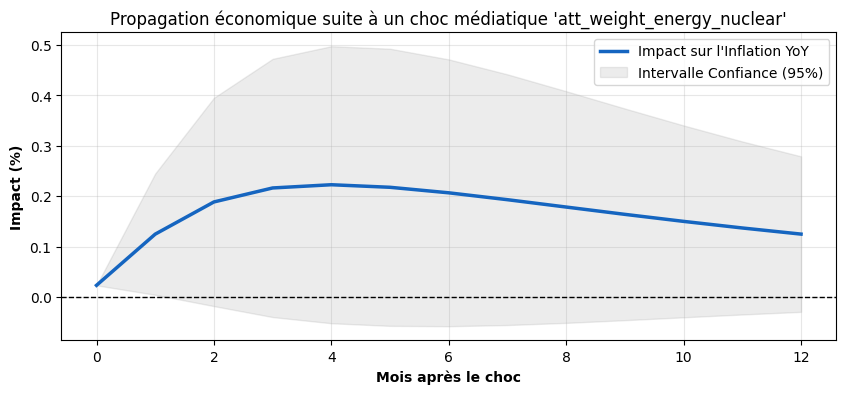


✅ FIN DE L'AUDIT POUR SOUTH AMERICA



In [9]:
# On définit tous les grands thèmes que l'on veut jeter dans l'arène de la Phase 1
mes_grands_secteurs = [
    "finance", "energy", "agriculture", "tech", 
    "industry", "commodities", "real_estate", "transport"
]

# On lance l'usine (Exemple pour les États-Unis)
run_hierarchical_pipeline(
    df_geo = df_geo, 
    region = "South America", 
    type_gdelt = "att_weight", 
    parent_sectors = mes_grands_secteurs,
    macro_tickers_dict = MACRO_TICKERS
)

🌍 AUDIT ÉCONOMÉTRIQUE HIÉRARCHIQUE : RUSSIA | IND. : ATT_WEIGHT

▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 PHASE 1 : COMPÉTITION DES GRANDS THÈMES (MACRO-NARRATIONS)
Objectif : Identifier les secteurs majeurs qui annoncent l'inflation (Lags T+1 à T+6).
Lecture  : Les cases foncées à droite (T > 0) sont vos Indicateurs Avancés robustes.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_finance,0.00,0.00,0.00,0.00,+0.08**,+0.19***,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_energy,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_agriculture,+0.16***,+0.32***,+0.24***,+0.15***,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_tech,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry,0.00,0.00,0.00,0.00,0.00,-0.09*,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_commodities,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_real_estate,0.00,0.00,0.00,0.00,0.00,-0.07 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_transport,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
_INERTIE_MACRO_,+0.87***,+1.20***,+1.43***,+1.61***,+1.72***,+1.94***,N/A,N/A,N/A,N/A,N/A,N/A,N/A




▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 PHASE 2 : DEEP DIVE SUR LES THÈMES GAGNANTS (2 trouvés)
Objectif : Pour chaque thème vainqueur, isoler la SOUS-CATÉGORIE exacte qui porte le signal.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

🔍 FORAGE DANS LE SECTEUR : ATT_WEIGHT_FINANCE


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_finance_banks,0.00,0.00,-0.39 (ns),+0.13 (ns),-0.12 (ns),+0.16**,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_central_banks,0.00,+0.02 (ns),+0.26 (ns),-0.06 (ns),+0.05 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_credit,0.00,0.00,0.00,+0.04 (ns),+0.17 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_financial_markets,0.00,0.00,-0.12 (ns),-0.27 (ns),-0.06 (ns),+0.17*,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_international_orgs,0.00,+0.04 (ns),-0.00 (ns),+0.18 (ns),+0.10 (ns),+0.01 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_private_debt,0.00,0.00,-0.92**,-1.03***,-1.19***,-0.00*,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_regulation,0.00,+0.19 (ns),-0.15 (ns),-0.07 (ns),-0.14 (ns),+0.04 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_sovereign_debt,0.00,+0.23 (ns),+1.42***,+1.34***,+1.29***,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_systemic_risk,0.00,0.00,+0.14 (ns),0.00,+0.23 (ns),-0.18***,0.00,0.00,0.00,0.00,0.00,0.00,0.00
_INERTIE_MACRO_,+0.45***,+1.28***,+1.51***,+1.73***,+1.69***,+2.02***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  🏆 Meilleure Narration détectée : ATT_WEIGHT_FINANCE_SOVEREIGN_DEBT (Impact: 1.42)

🔍 FORAGE DANS LE SECTEUR : ATT_WEIGHT_AGRICULTURE


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_agriculture_agribusiness,0.00,0.00,0.00,0.00,0.00,-0.13 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_agriculture_climate_risks,0.00,0.00,0.00,+0.08 (ns),0.00,-0.07 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_agriculture_food_prices,+0.66***,+0.79***,+0.61***,+0.46***,+0.13*,+0.24**,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_agriculture_infrastructure_tech,+0.26 (ns),+0.35**,+0.35**,+0.25*,0.00,+0.25**,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_agriculture_regulation,0.00,-0.10 (ns),0.00,-0.24*,+0.13**,-0.14 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_agriculture_rural_labor,0.00,0.00,-0.12 (ns),0.00,0.00,-0.08 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_agriculture_water,+0.17 (ns),+0.02 (ns),0.00,-0.09 (ns),-0.01 (ns),-0.04 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
_INERTIE_MACRO_,+1.31***,+1.57***,+1.71***,+1.81***,+1.86***,+2.02***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  🏆 Meilleure Narration détectée : ATT_WEIGHT_AGRICULTURE_FOOD_PRICES (Impact: 0.79)


▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 PHASE 3 : SIMULATION DE CRISE (FONCTIONS DE RÉPONSE IMPULSIONNELLE)
Objectif : Visualiser l'impact économique sur 12 mois d'un choc sur les meilleurs narratifs.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

💥 Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_FINANCE_SOVEREIGN_DEBT


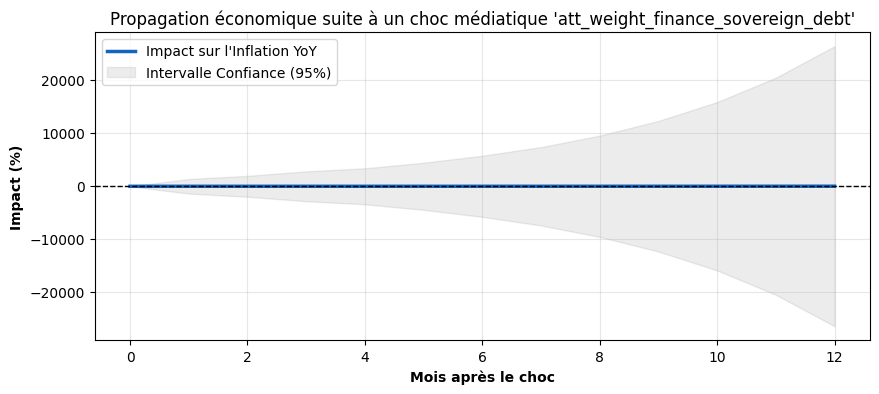


💥 Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_AGRICULTURE_FOOD_PRICES


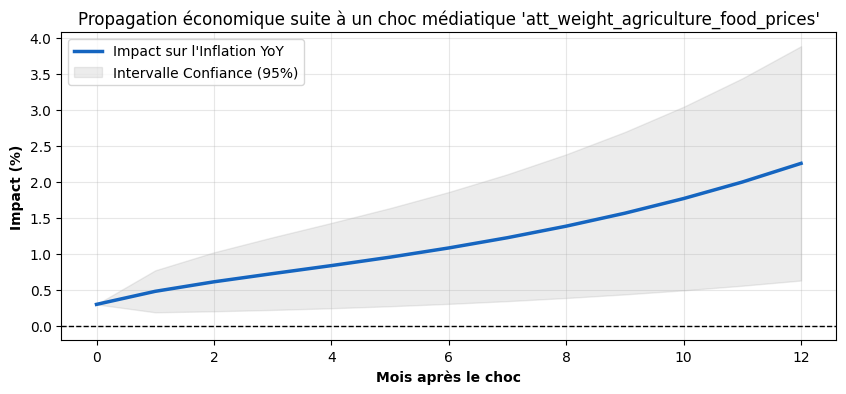


✅ FIN DE L'AUDIT POUR RUSSIA



In [10]:
# On définit tous les grands thèmes que l'on veut jeter dans l'arène de la Phase 1
mes_grands_secteurs = [
    "finance", "energy", "agriculture", "tech", 
    "industry", "commodities", "real_estate", "transport"
]

# On lance l'usine (Exemple pour les États-Unis)
run_hierarchical_pipeline(
    df_geo = df_geo, 
    region = "Russia", 
    type_gdelt = "att_weight", 
    parent_sectors = mes_grands_secteurs,
    macro_tickers_dict = MACRO_TICKERS
)

🌍 AUDIT ÉCONOMÉTRIQUE HIÉRARCHIQUE : SOUTH EAST ASIA | IND. : ATT_WEIGHT

▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 PHASE 1 : COMPÉTITION DES GRANDS THÈMES (MACRO-NARRATIONS)
Objectif : Identifier les secteurs majeurs qui annoncent l'inflation (Lags T+1 à T+6).
Lecture  : Les cases foncées à droite (T > 0) sont vos Indicateurs Avancés robustes.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_finance,+0.25**,+0.18*,+0.12 (ns),+0.14**,+0.12**,+0.04 (ns),+0.02**,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_energy,+0.23**,+0.13 (ns),+0.11 (ns),+0.15**,+0.11**,+0.03 (ns),0.00,0.00,0.00,0.00,0.00,-0.02**,0.00
att_weight_agriculture,+0.21 (ns),+0.22*,+0.18*,+0.17**,+0.13*,+0.07 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_tech,+0.31***,+0.25***,+0.18**,+0.11*,+0.10**,+0.07*,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry,-0.19*,-0.20**,-0.19**,-0.17**,-0.10*,-0.04 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_commodities,+0.12 (ns),+0.11 (ns),+0.17*,+0.14*,+0.14**,+0.07 (ns),0.00,0.00,0.00,0.00,0.00,-0.01**,0.00
att_weight_real_estate,-0.22*,-0.14 (ns),-0.15 (ns),-0.15*,-0.18***,-0.09*,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_transport,+0.28***,+0.24***,+0.24***,+0.17***,+0.13**,+0.05 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
_INERTIE_MACRO_,+0.69***,+0.79***,+0.89***,+0.97***,+1.05***,+1.12***,N/A,N/A,N/A,N/A,N/A,N/A,N/A




▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 PHASE 2 : DEEP DIVE SUR LES THÈMES GAGNANTS (8 trouvés)
Objectif : Pour chaque thème vainqueur, isoler la SOUS-CATÉGORIE exacte qui porte le signal.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

🔍 FORAGE DANS LE SECTEUR : ATT_WEIGHT_FINANCE


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_finance_banks,-0.27*,0.00,0.00,0.00,0.00,0.00,+0.37***,+0.33***,+0.14***,0.00,0.00,0.00,0.00
att_weight_finance_central_banks,+0.03 (ns),0.00,0.00,0.00,0.00,0.00,+0.03 (ns),0.00,0.00,0.00,0.00,0.00,-0.11***
att_weight_finance_credit,-0.07 (ns),0.00,0.00,0.00,0.00,0.00,+0.13 (ns),+0.14*,+0.06 (ns),0.00,0.00,0.00,0.00
att_weight_finance_financial_markets,+0.03 (ns),0.00,0.00,0.00,+0.01 (ns),0.00,-0.34***,-0.37***,-0.23***,0.00,0.00,0.00,0.00
att_weight_finance_international_orgs,+0.17*,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_private_debt,-0.42***,-0.13***,-0.08***,-0.14***,-0.15***,-0.04**,+0.15**,+0.16**,+0.13**,0.00,0.00,0.00,0.00
att_weight_finance_regulation,+0.07 (ns),0.00,0.00,0.00,+0.04 (ns),+0.01 (ns),+0.05 (ns),0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_sovereign_debt,+0.55***,+0.33***,+0.21***,+0.23***,+0.18***,+0.07***,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_finance_systemic_risk,+0.35***,+0.04**,0.00,0.00,+0.01 (ns),0.00,-0.11*,-0.05 (ns),0.00,0.00,0.00,0.00,0.00
_INERTIE_MACRO_,+0.65***,+0.63***,+0.72***,+0.88***,+0.97***,+1.06***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  🏆 Meilleure Narration détectée : ATT_WEIGHT_FINANCE_SOVEREIGN_DEBT (Impact: 0.55)

🔍 FORAGE DANS LE SECTEUR : ATT_WEIGHT_ENERGY


...

  ⚠ Aucune sous-catégorie n'a survécu à l'isolation.

🔍 FORAGE DANS LE SECTEUR : ATT_WEIGHT_REAL_ESTATE


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_real_estate_construction,+0.01 (ns),0.00,0.00,+0.01 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_real_estate_financing,+0.09 (ns),+0.06 (ns),+0.04 (ns),+0.01 (ns),+0.03 (ns),+0.03 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_real_estate_market,+0.09*,+0.10 (ns),+0.10 (ns),+0.07*,+0.02 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_real_estate_regulation,0.00,+0.04 (ns),+0.03 (ns),0.00,0.00,+0.00 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_real_estate_urbanism,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
_INERTIE_MACRO_,+0.51***,+0.66***,+0.79***,+0.89***,+0.95***,+1.06***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  ⚠ Aucune sous-catégorie n'a survécu à l'isolation.

🔍 FORAGE DANS LE SECTEUR : ATT_WEIGHT_TRANSPORT


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_transport_costs,+0.09 (ns),+0.10*,+0.08 (ns),+0.08*,+0.09*,+0.05 (ns),-0.10**,-0.21***,-0.24***,-0.34***,-0.39***,-0.39***,-0.41***
att_weight_transport_infrastructure,0.00,0.00,0.00,0.00,+0.01 (ns),+0.00 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_transport_international_trade,+0.08 (ns),+0.01 (ns),0.00,0.00,0.00,+0.01 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_transport_logistics,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_transport_modes,+0.06 (ns),+0.02 (ns),+0.06 (ns),+0.04 (ns),+0.00 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_transport_regulation,+0.11 (ns),+0.16 (ns),+0.14**,+0.09 (ns),+0.08 (ns),+0.03 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_transport_risks,0.00,0.00,-0.01 (ns),0.00,0.00,-0.01 (ns),+0.08**,+0.06**,+0.04*,+0.01 (ns),+0.00 (ns),0.00,0.00
_INERTIE_MACRO_,+0.56***,+0.68***,+0.80***,+0.92***,+1.01***,+1.09***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  🏆 Meilleure Narration détectée : ATT_WEIGHT_TRANSPORT_REGULATION (Impact: 0.14)


▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 PHASE 3 : SIMULATION DE CRISE (FONCTIONS DE RÉPONSE IMPULSIONNELLE)
Objectif : Visualiser l'impact économique sur 12 mois d'un choc sur les meilleurs narratifs.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

💥 Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_FINANCE_SOVEREIGN_DEBT


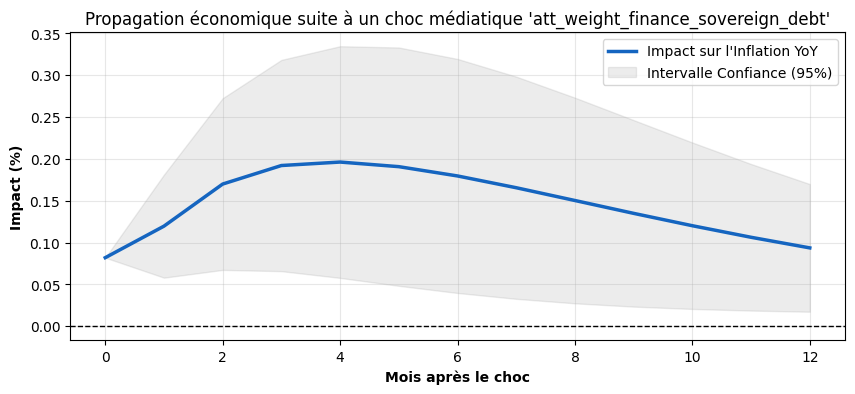


💥 Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_AGRICULTURE_AGRIBUSINESS


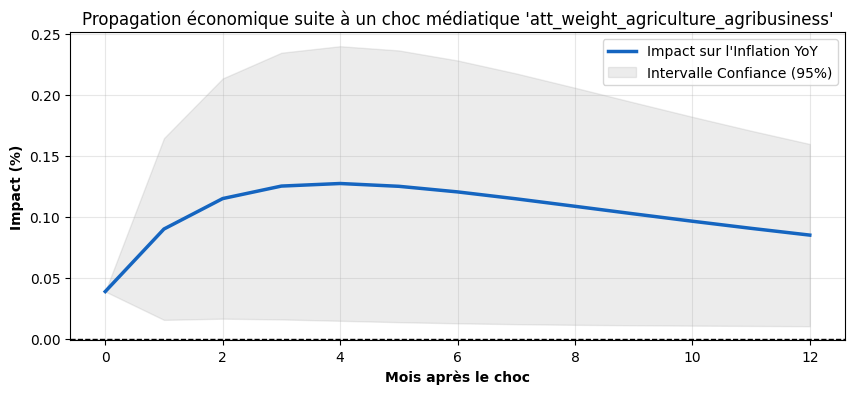


💥 Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_ENERGY_NUCLEAR


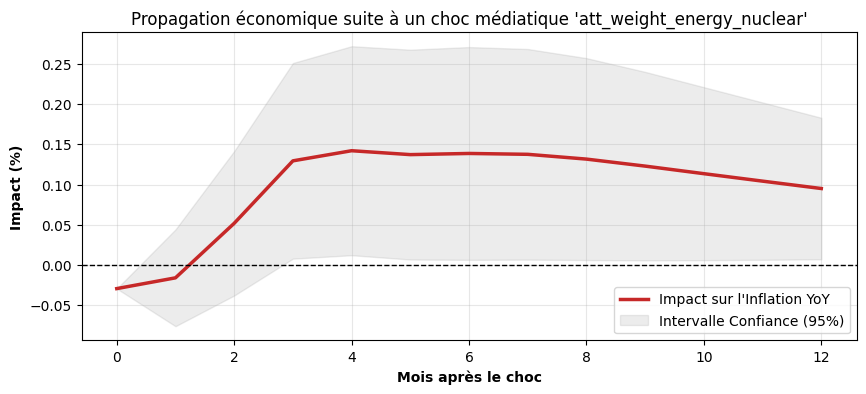


💥 Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_INDUSTRY_FACTORIES


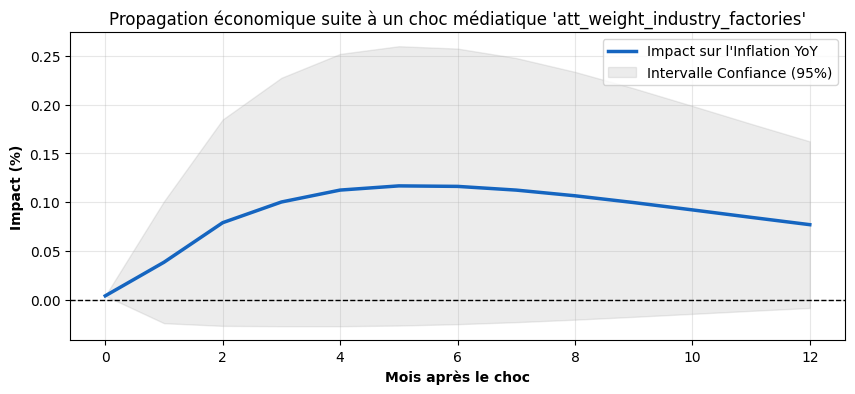


💥 Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_TECH_INFRASTRUCTURE


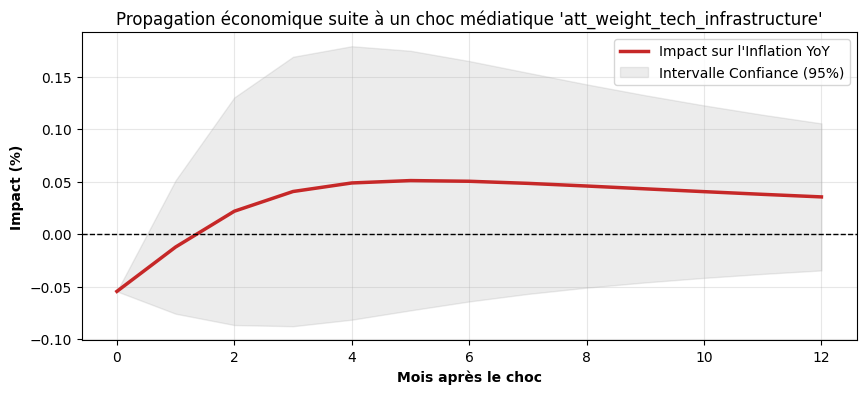


✅ FIN DE L'AUDIT POUR SOUTH EAST ASIA



In [11]:
# On définit tous les grands thèmes que l'on veut jeter dans l'arène de la Phase 1
mes_grands_secteurs = [
    "finance", "energy", "agriculture", "tech", 
    "industry", "commodities", "real_estate", "transport"
]

# On lance l'usine (Exemple pour les États-Unis)
run_hierarchical_pipeline(
    df_geo = df_geo, 
    region = "South East Asia", 
    type_gdelt = "att_weight", 
    parent_sectors = mes_grands_secteurs,
    macro_tickers_dict = MACRO_TICKERS
)

🌍 AUDIT ÉCONOMÉTRIQUE HIÉRARCHIQUE : AFRICA | IND. : ATT_WEIGHT

▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 PHASE 1 : COMPÉTITION DES GRANDS THÈMES (MACRO-NARRATIONS)
Objectif : Identifier les secteurs majeurs qui annoncent l'inflation (Lags T+1 à T+6).
Lecture  : Les cases foncées à droite (T > 0) sont vos Indicateurs Avancés robustes.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_finance,+0.35***,+0.30***,+0.22**,+0.20**,+0.17**,0.00,+0.63***,+0.67***,+0.60***,+0.48***,+0.36***,+0.26**,+0.14*
att_weight_energy,+0.14**,+0.15*,+0.11*,+0.18**,+0.20***,+0.06**,+0.17*,+0.10 (ns),+0.02 (ns),0.00,0.00,-0.08 (ns),-0.11 (ns)
att_weight_agriculture,+0.03 (ns),+0.05 (ns),+0.01 (ns),+0.04 (ns),0.00,0.00,-0.24**,-0.20*,-0.23**,-0.25**,-0.27***,-0.36***,-0.36***
att_weight_tech,0.00,+0.10 (ns),+0.05 (ns),+0.03 (ns),+0.00 (ns),0.00,0.00,+0.08 (ns),+0.16 (ns),+0.18*,+0.19*,+0.29**,+0.27**
att_weight_industry,-0.23***,-0.28***,-0.17***,-0.18***,-0.11**,0.00,-0.25**,-0.29**,-0.17 (ns),-0.08 (ns),-0.06 (ns),-0.13 (ns),-0.12 (ns)
att_weight_commodities,0.00,0.00,0.00,0.00,0.00,+0.03 (ns),+0.29**,+0.20 (ns),+0.21*,+0.22*,+0.23**,+0.30**,+0.32***
att_weight_real_estate,+0.06 (ns),+0.07 (ns),+0.05 (ns),+0.04 (ns),+0.01 (ns),0.00,0.00,+0.04 (ns),+0.05 (ns),+0.02 (ns),0.00,+0.03 (ns),+0.03 (ns)
att_weight_transport,0.00,+0.10 (ns),+0.09 (ns),+0.06 (ns),+0.05 (ns),0.00,0.00,0.00,0.00,+0.03 (ns),0.00,0.00,0.00
_INERTIE_MACRO_,+0.62***,+0.73***,+0.85***,+0.97***,+1.10***,+1.27***,N/A,N/A,N/A,N/A,N/A,N/A,N/A




▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 PHASE 2 : DEEP DIVE SUR LES THÈMES GAGNANTS (3 trouvés)
Objectif : Pour chaque thème vainqueur, isoler la SOUS-CATÉGORIE exacte qui porte le signal.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

🔍 FORAGE DANS LE SECTEUR : ATT_WEIGHT_FINANCE


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_finance_banks,0.00,0.00,0.00,0.00,0.00,0.00,+0.43**,+0.49***,+0.57***,+0.39***,+0.36***,0.00,+0.03 (ns)
att_weight_finance_central_banks,+0.20 (ns),+0.20 (ns),+0.19 (ns),+0.20*,+0.17*,+0.02 (ns),-0.02 (ns),-0.03 (ns),-0.17 (ns),0.00,0.00,0.00,0.00
att_weight_finance_credit,0.00,0.00,0.00,0.00,+0.01 (ns),+0.01 (ns),+0.18 (ns),+0.21*,+0.19 (ns),0.00,0.00,0.00,0.00
att_weight_finance_financial_markets,0.00,0.00,0.00,-0.00 (ns),-0.04 (ns),0.00,+0.15 (ns),+0.13 (ns),+0.14 (ns),+0.07 (ns),+0.08 (ns),0.00,+0.20***
att_weight_finance_international_orgs,+0.04 (ns),+0.11*,+0.07*,+0.04*,+0.00 (ns),0.00,+0.10 (ns),+0.11 (ns),+0.08 (ns),0.00,0.00,0.00,0.00
att_weight_finance_private_debt,-0.47***,-0.44***,-0.33***,-0.20***,-0.13***,-0.09***,-0.31 (ns),-0.08 (ns),-0.05 (ns),0.00,0.00,0.00,0.00
att_weight_finance_regulation,+0.12 (ns),+0.03 (ns),0.00,0.00,0.00,0.00,+0.21 (ns),+0.19 (ns),+0.16 (ns),+0.05 (ns),0.00,0.00,0.00
att_weight_finance_sovereign_debt,+0.56***,+0.52***,+0.43***,+0.28***,+0.21***,+0.14***,+0.55**,+0.34*,+0.37 (ns),+0.15 (ns),+0.04 (ns),0.00,0.00
att_weight_finance_systemic_risk,0.00,0.00,0.00,0.00,0.00,0.00,-0.39***,-0.34***,-0.26*,0.00,0.00,0.00,0.00
_INERTIE_MACRO_,+0.61***,+0.70***,+0.81***,+0.92***,+1.07***,+1.27***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  🏆 Meilleure Narration détectée : ATT_WEIGHT_FINANCE_SOVEREIGN_DEBT (Impact: 0.56)

🔍 FORAGE DANS LE SECTEUR : ATT_WEIGHT_ENERGY


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_energy_fossil,0.00,0.00,0.00,+0.00 (ns),+0.12*,+0.11***,+0.01 (ns),0.00,0.00,0.00,0.00,0.00,0.00
att_weight_energy_infrastructures,0.00,+0.09*,+0.04 (ns),+0.01 (ns),+0.00 (ns),+0.00 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_energy_nuclear,+0.22***,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_energy_regulation,0.00,0.00,0.00,0.00,0.00,0.00,+0.05 (ns),0.00,+0.08*,+0.09*,+0.08*,0.00,0.00
att_weight_energy_renewables,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_energy_risks,0.00,+0.04 (ns),+0.11*,+0.18***,+0.20***,+0.08**,+0.15**,0.00,+0.14**,+0.13**,+0.13**,0.00,0.00
_INERTIE_MACRO_,+0.79***,+0.83***,+0.94***,+1.01***,+1.12***,+1.28***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  🏆 Meilleure Narration détectée : ATT_WEIGHT_ENERGY_NUCLEAR (Impact: 0.22)

🔍 FORAGE DANS LE SECTEUR : ATT_WEIGHT_INDUSTRY


,T+6,T+5,T+4,T+3,T+2,T+1,T(0),T-1,T-2,T-3,T-4,T-5,T-6
att_weight_industry_factories,0.00,0.00,+0.02 (ns),0.00,+0.03 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry_logistics,+0.09 (ns),+0.15*,+0.09 (ns),0.00,+0.03 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry_productivity,0.00,0.00,0.00,0.00,+0.02 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry_regulation,-0.31***,-0.30***,-0.21***,-0.10**,-0.11**,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry_risks,0.00,0.00,0.00,0.00,-0.02 (ns),0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
att_weight_industry_supply_chains,+0.24***,+0.17**,+0.08 (ns),+0.07*,+0.10 (ns),+0.04*,0.00,0.00,0.00,0.00,0.00,0.00,0.00
_INERTIE_MACRO_,+0.79***,+0.87***,+0.97***,+1.06***,+1.18***,+1.30***,N/A,N/A,N/A,N/A,N/A,N/A,N/A


  🏆 Meilleure Narration détectée : ATT_WEIGHT_INDUSTRY_REGULATION (Impact: 0.31)


▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📌 PHASE 3 : SIMULATION DE CRISE (FONCTIONS DE RÉPONSE IMPULSIONNELLE)
Objectif : Visualiser l'impact économique sur 12 mois d'un choc sur les meilleurs narratifs.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

💥 Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_FINANCE_SOVEREIGN_DEBT


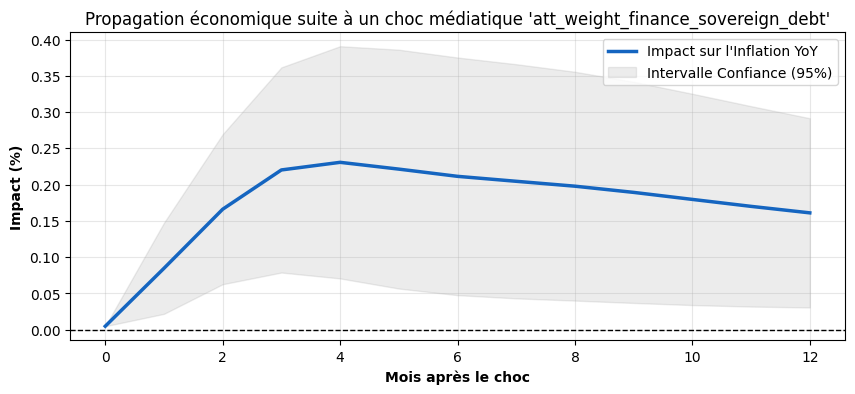


💥 Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_INDUSTRY_REGULATION


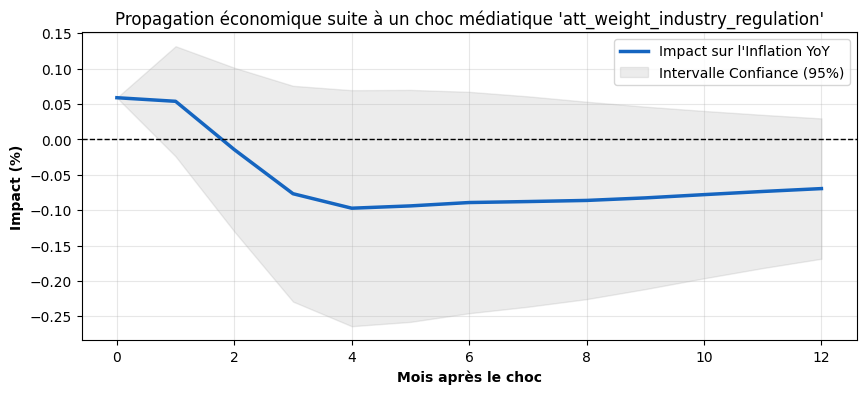


💥 Choc Simulatif (+1 Écart-type) sur le récit : ATT_WEIGHT_ENERGY_NUCLEAR


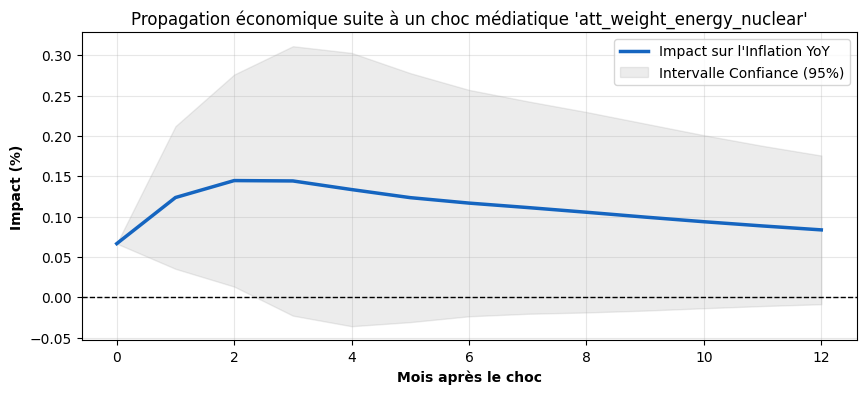


✅ FIN DE L'AUDIT POUR AFRICA



In [12]:
# On définit tous les grands thèmes que l'on veut jeter dans l'arène de la Phase 1
mes_grands_secteurs = [
    "finance", "energy", "agriculture", "tech", 
    "industry", "commodities", "real_estate", "transport"
]

# On lance l'usine (Exemple pour les États-Unis)
run_hierarchical_pipeline(
    df_geo = df_geo, 
    region = "Africa", 
    type_gdelt = "att_weight", 
    parent_sectors = mes_grands_secteurs,
    macro_tickers_dict = MACRO_TICKERS
)